In [1]:
import os
import itertools
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as c
from scipy.signal import fftconvolve
from q3dfit.q3din import q3din
from q3dfit.q3dout import q3dout, load_q3dout
from q3dfit.q3df import q3dfit
from q3dfit import q3dutil
from q3dfit.checkcomp import checkcomp
from q3dfit.q3dcollect import q3dcollect
from q3dfit.linelist import linelist

In [2]:
def order_map2(shape: tuple, start_positions: list[tuple]):
    x = np.arange(shape[0])
    y = np.arange(shape[1])
    xx, yy = np.meshgrid(x,y, indexing="ij")
    dist = np.full((*shape, len(start_positions)), fill_value=np.inf)
    for i, start in enumerate(start_positions):
        x0, y0 = start
        dist[:,:,i] = np.abs(xx-x0) + np.abs(yy-y0)
    return dist.min(axis=2)

In [3]:
def order_map(shape: tuple, start_positions: list[tuple]):
    map = np.full(shape, fill_value=np.inf)
    for start in start_positions:
        assert (start[0] != 0) & (start[1] != 0), "start cant be on the border"
        assert (start[0] != shape[0]-1) & (start[1] != shape[1]-1), "start cant be on the border"
        for j in (-1,0,1):
            map[start[0]+j, start[1]] = 1
            map[start[0], start[1]+j] = 1
        map[*start] = 0
    i = 0
    while map.max() == np.inf:
        i += 1
        # number of neighbors already fit
        num_neighbors = fftconvolve(np.where(map <= i, 1, 0), np.ones((3,3)), mode="same").round().astype(int)
        map[(num_neighbors >= 3) & ~(map <= i)] = i+1
    return map

Decreased minimum at step 3 to 2
[[15. 14. 14. 14. 15.]
 [13. 12. 13. 12. 13.]
 [ 5.  5. 11. 10. 11.]
 [ 2.  1.  6.  7.  9.]
 [ 1.  0.  2.  5.  8.]
 [ 2.  1.  3.  5.  9.]]


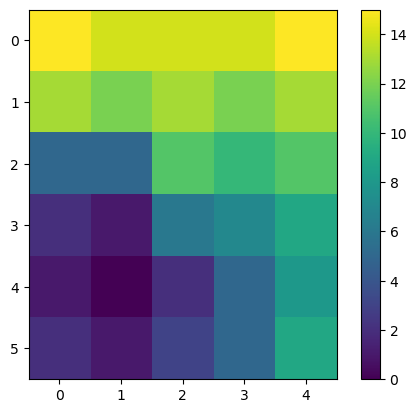

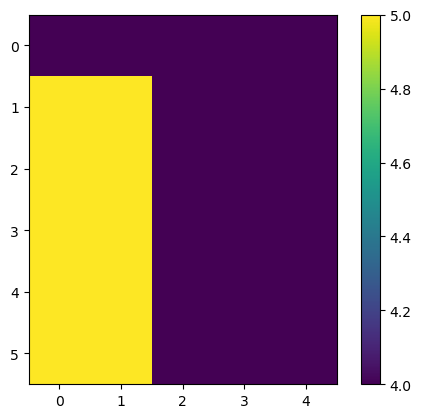

In [4]:
def order_map_with_ncomp1(ncomp_map: np.ndarray, start_positions: list[tuple], one_indexed=True):
    shape = ncomp_map.shape
    map = np.full(shape, fill_value=np.inf)
    for start in start_positions:
        assert (start[0] != 0) & (start[1] != 0), "start cant be on the border"
        assert (start[0] != shape[0]-1) & (start[1] != shape[1]-1), "start cant be on the border"
    if one_indexed:
        start_positions = [(start[0]-1, start[1]-1) for start in start_positions]
    for start in start_positions:
        for j in (-1,0,1):
            if ncomp_map[*start] == ncomp_map[start[0]+j, start[1]]:
                map[start[0]+j, start[1]] = 1
            if ncomp_map[*start] == ncomp_map[start[0], start[1]+j]:
                map[start[0], start[1]+j] = 1
        map[*start] = 0
    i = 0
    import time
    t0 = time.time()
    last_map = map.copy()
    minimum_neighbours = 3
    while map.max() == np.inf:
        i += 1
        # number of neighbors already fit
        num_neighbors = fftconvolve(np.where(map <= i, 1, 0), np.ones((3,3)), mode="same").round().astype(int)
        candidates = (num_neighbors >= minimum_neighbours) & ~(map <= i)
        col, row = np.where(candidates)
        for c, r in zip(col, row):
            neighbours = np.zeros_like(ncomp_map)
            neighbours[max(c-1,0):min(c+2,shape[0]), max(r-1,0):min(r+2,shape[1])] = ncomp_map[max(c-1,0):min(c+2,shape[0]), max(r-1,0):min(r+2,shape[1])]
            if ncomp_map[c,r] == 0:
                ...
            elif np.where((neighbours == ncomp_map[c,r]) & (map <= i), 1, 0).sum() >= minimum_neighbours:
                # do neighbours of same ncomp
                map[c,r] = i+1
            elif np.where((neighbours >= ncomp_map[c,r]) & (map <= i), 1, 0).sum() == 0:
                # if all neighbours are lower do nothing
                ...
            elif np.array_equal(np.where((neighbours > ncomp_map[c,r]) & (map <= i), 1, 0), np.where(neighbours > ncomp_map[c,r], 1, 0)):
                # if all higher neighbours are done
                map[c,r] = i+1
        if np.array_equal(last_map, map):
            minimum_neighbours -= 1
            if minimum_neighbours == 0:
                print(f"Minimum reached 0 at step {i}")
                break
            print(f"Decreased minimum at step {i} to {minimum_neighbours}")
        else:
            minimum_neighbours = 3
        last_map = map.copy()
        if time.time() - t0 > 5:
            break
    return map

testmap = np.array([[4,4,4,4,4],[5,5,4,4,4],[5,5,4,4,4],[5,5,4,4,4],[5,5,4,4,4],[5,5,4,4,4]])
start = [(4,1)]
map = order_map_with_ncomp1(testmap, start, one_indexed=False)
print(map)
plt.imshow(map)
plt.colorbar()
plt.show()
plt.imshow(testmap)
plt.colorbar()
plt.show()

Decreased minimum at step 3 to 2
Decreased minimum at step 5 to 2
Reduced ncomp at step 7 to 4
Decreased minimum at step 14 to 2
Reduced ncomp at step 16 to 3
[[16. 16. 18.  1.  9.]
 [ 7.  7. 18.  0.  1.]
 [ 5.  5. 18. 18. 18.]
 [ 3.  1.  9. 12. 14.]
 [ 1.  0.  9. 11. 13.]
 [ 3.  1. 10. 12. 14.]]


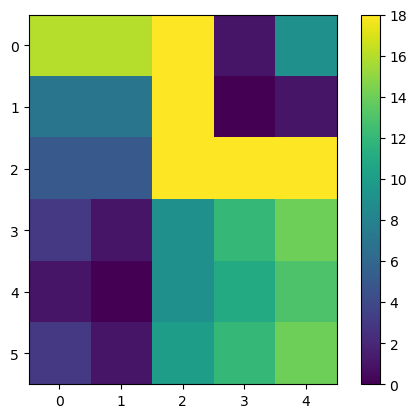

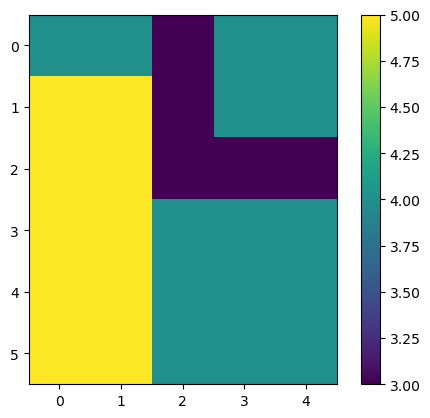

In [2]:
def order_map_with_ncomp(ncomp_map: np.ndarray, start_positions: list[tuple], one_indexed=True):
    shape = ncomp_map.shape
    map = np.full(shape, fill_value=np.inf)
    for start in start_positions:
        assert (start[0] != 0) & (start[1] != 0), "start cant be on the border"
        assert (start[0] != shape[0]-1) & (start[1] != shape[1]-1), "start cant be on the border"
    if one_indexed:
        start_positions = [(start[0]-1, start[1]-1) for start in start_positions]

    i = 0
    import time
    t0 = time.time()
    last_map = map.copy()
    minimum_neighbours = 3
    current_ncomp = ncomp_map.max()+1
    while map.max() == np.inf:
        i += 1
        # number of neighbors already fit
        num_neighbors = fftconvolve(np.where(map <= i, 1, 0), np.ones((3,3)), mode="same").round().astype(int)
        # choose pixels with one neighbour already fit with same ncomp
        candidates = (num_neighbors >= 1) & ~(map <= i) & (ncomp_map == current_ncomp)
        col, row = np.where(candidates)
        # go through candidates
        for c, r in zip(col, row):
            neighbours = np.zeros_like(ncomp_map)
            d1 = slice(max(c-1,0),min(c+2,shape[0]))
            d2 = slice(max(r-1,0),min(r+2,shape[1]))
            neighbours[d1,d2] = ncomp_map[d1,d2]

            if ncomp_map[c,r] == 0:
                ...  # discard any pixel with 0 components
            elif np.where((neighbours >= ncomp_map[c,r]) & (map <= i), 1, 0).sum() >= minimum_neighbours:
                # if pixel has "minumum_neigbours" number of neighbours of same ncomp or higher
                map[c,r] = i+1
            elif np.where((neighbours >= ncomp_map[c,r]) & (map <= i), 1, 0).sum() == 0:
                # if all neighbours are lower do nothing
                ...

        if np.array_equal((map <= i), ncomp_map >= current_ncomp):  # check if all of current_ncomp are done
            current_ncomp -= 1
            if current_ncomp == 0:
                print(f"ncomp reached 0 at step {i}")
                break
            if current_ncomp != ncomp_map.max():
                print(f"Reduced ncomp at step {i} to {current_ncomp}")
            for start in start_positions:
                if ncomp_map[*start] == current_ncomp:
                    for j in (-1,0,1):
                        if ncomp_map[start[0]+j, start[1]] == current_ncomp:
                            map[start[0]+j, start[1]] = 1
                        if ncomp_map[start[0], start[1]+j] == current_ncomp:
                            map[start[0], start[1]+j] = 1
                    map[*start] = 0
        elif np.array_equal(last_map, map):  # check if nothing happend last cycle
            minimum_neighbours -= 1
            if minimum_neighbours == 0:
                print(f"Minimum reached 0 at step {i}")
                break
            print(f"Decreased minimum at step {i} to {minimum_neighbours}")
        else:
            minimum_neighbours = 3
        last_map = map.copy()
        if time.time() - t0 > 5:
            break
    return map

testmap = np.array([[4,4,3,4,4],[5,5,3,4,4],[5,5,3,3,3],[5,5,4,4,4],[5,5,4,4,4],[5,5,4,4,4]])
start = [(4,1),(1,3)]
map = order_map_with_ncomp(testmap, start, one_indexed=False)
print(map)
plt.imshow(map)
plt.colorbar()
plt.show()
plt.imshow(testmap)
plt.colorbar()
plt.show()

In [3]:
starting_positions = [(6,26), (22,35), (26,38), (37,42), (36,69), (52,73), (17,51), (65,75), (47,44), (28,54), (10,64), (30,17), (17,13), (56,41)]
rmf_map = np.load("smoothed_rmf_map.npy")
final_map = order_map_with_ncomp(rmf_map, starting_positions)
# plt.imshow(final_map.T, origin="lower")
# plt.colorbar()
# plt.show()
# plt.imshow(rmf_map.T, origin="lower")
# plt.show()

Reduced ncomp at step 10 to 4
Reduced ncomp at step 21 to 3
Decreased minimum at step 31 to 2
Decreased minimum at step 33 to 2
Reduced ncomp at step 35 to 2
Decreased minimum at step 71 to 2
Decreased minimum at step 73 to 2
Decreased minimum at step 75 to 2
Decreased minimum at step 77 to 2
Reduced ncomp at step 80 to 1
Decreased minimum at step 117 to 2
Decreased minimum at step 122 to 2
Decreased minimum at step 124 to 2
Decreased minimum at step 127 to 2
Decreased minimum at step 129 to 2
Decreased minimum at step 130 to 1
Minimum reached 0 at step 131


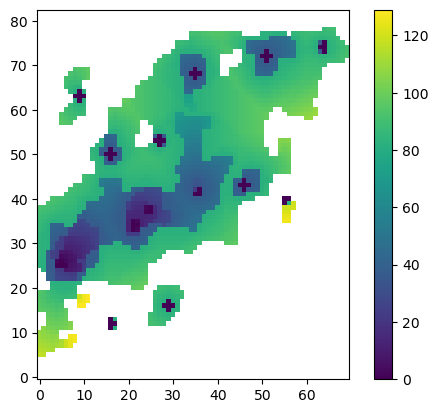

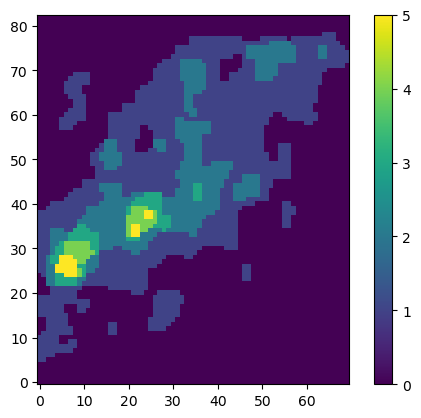

In [5]:
plt.imshow(final_map.T, origin="lower")
plt.colorbar()
plt.savefig(os.path.join("plots", "fitorder.pdf"))
plt.show()
plt.imshow(rmf_map.T, origin="lower")
plt.colorbar()
plt.savefig(os.path.join("plots", "OIII_ncomp_map.pdf"))
plt.show()

In [8]:
# global parameters
label = "4C1971_neighbour_method"
infile = "4C1971_G235H_NRS1_NRS2_s3d.fits"
outdir = "output"
redshift = 3.5892
fitrange = [2.16, 2.375]
ncores = 22

# infile_wo_cont = label+"_wo_continuum.fits"
# infile_converted_units = label+"_converted_units.fits"

indir = "input"
logdir = "logfiles"
if not os.path.exists(indir):
    os.makedirs(indir)

cols, rows = None, None
# lines to fit (name & wavelength)
lines = ['Hbeta', '[OIII]4959', '[OIII]5007']
line_wavelengths = list(linelist(lines)["lines"]) # micron
c_kms = c.c.to("km/s").value

In [9]:
def init_fit_neighbour_method(maxncomp):
    # set up directories
    outdir_n = outdir + "_neighbour_method"
    if not os.path.exists(outdir_n):
        os.makedirs(outdir_n)
    logdir_n = logdir + "_neighbour_method"
    if not os.path.exists(logdir_n):
        os.makedirs(logdir_n)

    logfile = os.path.join(logdir_n, label+"-fitlog.txt")
    q3di = q3din(infile, label, outdir=outdir_n, logfile=logfile)
    q3di.argsreadcube = {"wmapext": None, "fluxnorm": 1e-17, "usebunit": True}
    cube = q3di.load_cube()
    q3di.name = label
    q3di.zsys_gas = redshift
    q3di.fitrange = fitrange

    # line fit
    q3di.init_linefit(lines, linetie='[OIII]5007', maxncomp=maxncomp, checkcomp=False)
    q3di.spect_convol['ws_instrum'] = {'JWST_NIRSPEC':['G235H']}
    q3di.siglim_gas = np.array([40., 1000.])
    # q3di.argslineinit['flxlim'] = np.array([0., 1e-14]) / cube.fluxnorm
    q3di.argslinefit['method'] = 'least_squares'
    q3di.argslinefit['ftol'] = 1.e-8
    q3di.argslinefit['gtol'] = 1.e-8
    q3di.argslinefit['xtol'] = 1.e-8
    q3di.argslinefit['x_scale'] = 'jac'
    q3di.argslinefit['tr_solver'] = 'lsmr'

    q3di.argscheckcomp['sigcut'] = 3.
    q3di.argscheckcomp['ignore']= ['Hbeta']
    q3di.perror_useresid = True

    q3di.snr = 3.0
    q3di.snr_thresh = None

    for line in lines:
        # standard values if not specified
        q3di.zinit_gas[line][:,:,:] = q3di.zsys_gas  
        q3di.siginit_gas[line][:,:,:] = 200.
        q3di.ncomp[line][:,:] = 0

    # continum fit
    q3di.init_contfit("fitpoly")
    q3di.argscontfit.update({"fitord": 1})
    q3di.maskwidths_def = 4000
    q3di.masksig_secondfit = 4

    filename_q3di = os.path.join(indir, f"q3di_{label}.npy")
    q3di.filename = filename_q3di
    np.save(filename_q3di, q3di)
    return q3di

In [10]:
q3di = init_fit_neighbour_method(5)

Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: MJy/sr
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.


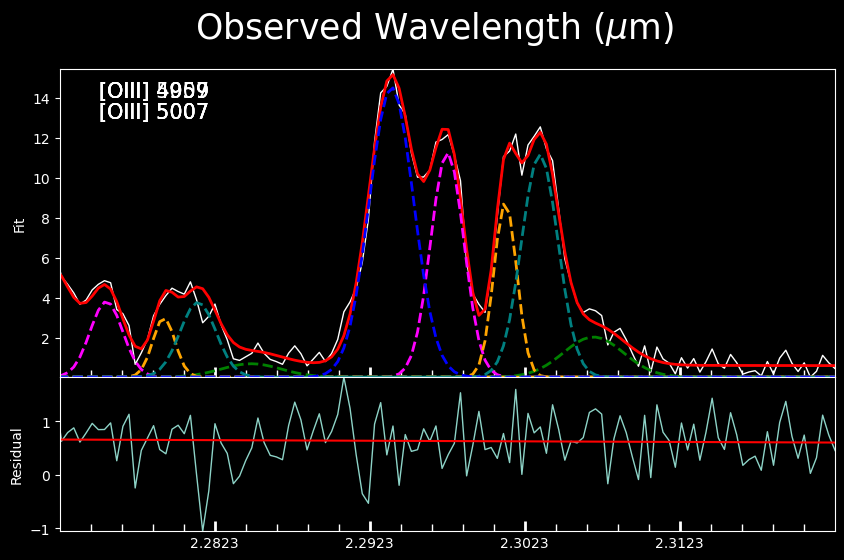

In [11]:
q3di_fm: q3din = q3dutil.get_q3dio("input/q3di_4C1971_from_map.npy")
q3do: q3dout = load_q3dout(q3di_fm, 6, 26)
q3do.plot_line(q3di_fm, plotargs={"line": ["[OIII]5007"], "nx": 1, "size": [0.05, 0.07], "figsize": (10,6)})

In [12]:
def load_flx_wav_sig(file):
    data = np.load(file, allow_pickle=True)
    flx = data["emlflx"].item()
    wave = data["emlwav"].item()
    sig = data["emlsig"].item()
    return flx, wave, sig

In [ ]:
# init_flx, init_wave, init_sig = load_flx_wav_sig("output_from_map/4C1971.line.npz")

# col, row = 7, 25
# init_col, init_row = 6, 26
# for line, line_wavelength in zip(lines, line_wavelengths):
#     for i in range(q3di.maxncomp):
#         q3di.fluxinit[line][col-1, row-1, i] = init_flx[f"fc{i+1}pk"][line][init_col-1, init_row-1]
#         q3di.zinit_gas[line][col-1, row-1, i] = init_wave[f"c{i+1}"][line][init_col-1, init_row-1] / line_wavelength - 1
#         q3di.siginit_gas[line][col-1, row-1, i] = init_sig[f"c{i+1}"][line][init_col-1, init_row-1]
# np.save(q3di.filename, q3di)
# q3dfit(q3di.filename, col, row, onefit=True)
# q3do_new = load_q3dout(q3di, col, row)
# q3do_new.plot_line(q3di, plotargs={"line": ["[OIII]5007"], "nx": 1, "size": [0.05, 0.07], "figsize": (10,6)})

plot_line: no lines to plot!


In [ ]:
# col, row = 7, 25
# for line, line_wavelength in zip(lines, line_wavelengths):
#     for i, flx in enumerate(q3do.line_fitpars["fluxpk"][line]):
#         q3di.fluxinit[line][col-1, row-1, i] = flx
#     for i, wave in enumerate(q3do.line_fitpars["wave"][line]):
#         q3di.zinit_gas[line][col-1, row-1, i] = wave / line_wavelength - 1  # convert to redshift
#     for i, sig in enumerate(q3do.line_fitpars["sigma"][line]):
#         q3di.siginit_gas[line][col-1, row-1, i] = sig
# np.save(q3di.filename, q3di)
# q3dfit(q3di.filename, col, row, onefit=True)
# q3do_new = load_q3dout(q3di, col, row)
# q3do_new.plot_line(q3di, plotargs={"line": ["[OIII]5007"], "nx": 1, "size": [0.05, 0.07], "figsize": (10,6)})

plot_line: no lines to plot!


In [152]:
def get_already_fit_neighbours(col, row, order_map, ncomp_map):
    col += 1
    row += 1
    order_map = np.pad(order_map, 1, "constant", constant_values=order_map.max()+1)
    ncomp_map = np.pad(ncomp_map, 1, "constant", constant_values=-1)
    d1 = slice(max(col-1,0),min(col+2,order_map.shape[0]))
    d2 = slice(max(row-1,0),min(row+2,order_map.shape[1]))
    col_diff, row_diff = np.where((ncomp_map[d1, d2] >= ncomp_map[col, row]) & (order_map[d1, d2] < max(order_map[col, row], 0.5)))
    return col+col_diff-2, row+row_diff-2

def set_initial_value(q3di, q3do, col, row, order_map, ncomp_map, select_components=None, skip_neighbours=None):
    if skip_neighbours is None:
        skip_neighbours = []
    for line, line_wavelength in zip(lines, line_wavelengths):
        # collect fit results from neighbouring spaxels
        collect_flux = []
        collect_wave = []
        collect_sig = []
        for c, r in zip(*get_already_fit_neighbours(col, row, order_map, ncomp_map)):
            # try:
            if (int(c), int(r)) in skip_neighbours:
                continue
            if select_components is not None:
                if ncomp_map[c, r] > ncomp_map[col, row]:
                    collect_flux.append(q3do[c, r].line_fitpars["fluxpk"][line].take(select_components).tolist())
                    collect_wave.append(q3do[c, r].line_fitpars["wave"][line].take(select_components).tolist())
                    collect_sig.append(q3do[c, r].line_fitpars["sigma"][line].take(select_components).tolist())
                else:
                    collect_flux.append(q3do[c, r].line_fitpars["fluxpk"][line].tolist()[:ncomp_map[col, row]])
                    collect_wave.append(q3do[c, r].line_fitpars["wave"][line].tolist()[:ncomp_map[col, row]])
                    collect_sig.append(q3do[c, r].line_fitpars["sigma"][line].tolist()[:ncomp_map[col, row]])
            else:
                collect_flux.append(q3do[c, r].line_fitpars["fluxpk"][line].tolist())
                collect_wave.append(q3do[c, r].line_fitpars["wave"][line].tolist())
                collect_sig.append(q3do[c, r].line_fitpars["sigma"][line].tolist())
            if (select_components is not None) and (line == "[OIII]5007"):
                print(f"[{col:d}, {row:d}]: [{c:d}, {r:d}] has Sigma {collect_sig[-1]}")
            # except AttributeError as e:
            #     print(f"[{col:d}, {row:d}]: [{c:d}, {r:d}]")
            #     raise e

        flux_init = np.nanmedian(np.array(collect_flux), axis=0)
        wave_init = np.nanmedian(np.array(collect_wave), axis=0)
        sig_init = np.nanmedian(np.array(collect_sig), axis=0)
        # set inital values for new spaxel
        # try:
        q3di.ncomp[line][col, row] = ncomp_map[col, row]
        for i, flx in enumerate(flux_init):
            q3di.fluxinit[line][col, row, i] = flx
        for i, wave in enumerate(wave_init):
            q3di.zinit_gas[line][col, row, i] = wave / line_wavelength - 1  # convert to redshift
        for i, sig in enumerate(sig_init):
            q3di.siginit_gas[line][col, row, i] = sig
        # except TypeError as e:
        #     print(flux_init)
        #     print(wave_init)
        #     print(sig_init)
        #     print(collect_flux)
        #     print(collect_wave)
        #     print(collect_sig)
        #     raise e
    # fit and save results
    np.save(q3di.filename, q3di)

def get_best_components(q3di, q3do, cols, rows, order_map, ncomp_map, current_ncomp, selected_components_array):
    component_combinations = list(itertools.combinations(range(ncomp_map.max()), current_ncomp))
    bic_values = np.full((*order_map.shape, len(component_combinations)), fill_value=np.inf, dtype=np.float64)
    for i, components in enumerate(component_combinations):
        for col, row in zip(cols, rows):
            set_initial_value(q3di, q3do, col, row, order_map, ncomp_map, select_components=components)
        # fit
        if len(cols) <= 2:
            for col, row in zip(cols, rows):
                q3dfit(q3di.filename, col+1, row+1, onefit=True, ncores=1, quiet=True, nocrash=True)
        else:
            q3dfit(q3di.filename, cols.tolist(), rows.tolist(), onefit=True, ncores=int(min(ncores, len(cols))), quiet=True, nocrash=True)
        for col, row in zip(cols, rows):
            q3do_test = load_q3dout(q3di, col+1, row+1)
            bic_values[col, row, i] = q3do_test.bic
    # select best component for each spaxel
    for col, row in zip(cols, rows):
        selected_components_array[col, row] = component_combinations[np.argmin(bic_values[col, row, :])]
        print(f"Best components for ({col:d}, {row:d}): {selected_components_array[col, row]}")
    return selected_components_array

def fit_neighbour_method(q3di, order_map, ncomp_map, previous_q3di):
    step_number_list, spaxels_per_step = np.unique(order_map, return_counts=True)
    q3do = np.empty(order_map.shape, dtype=q3dout)
    selected_components_array = np.empty(order_map.shape, dtype=tuple)

# step 0: load from previous fit
    cols, rows = np.where(order_map == 0.)
    for col, row in zip(cols, rows):
        previous_q3di: q3din = q3dutil.get_q3dio(previous_q3di)
        q3do[col, row] = load_q3dout(previous_q3di, col+1, row+1)

# step 1: fit from origin spaxel
    cols, rows = np.where(order_map <= 1.)
    for col, row in zip(cols, rows):
        set_initial_value(q3di, q3do, col, row, order_map, ncomp_map)

    print(f"Fit first step with {np.sum(spaxels_per_step[:2])} spaxels")
    q3dfit(q3di.filename, cols.tolist(), rows.tolist(), onefit=True, ncores=int(min(ncores, spaxels_per_step[1])), quiet=True, nocrash=True)
    for col, row in zip(cols, rows):
        q3do[col, row] = load_q3dout(q3di, col+1, row+1)

# step >= 2: fit from multiple spaxels
    current_ncomp = ncomp_map.max()
    current_ncomp_just_changed = False
    for step_number, spaxels_in_this_step in zip(step_number_list[2:], spaxels_per_step[2:]):
        if step_number == np.inf:
            break
        print(f"Fit Step {step_number} with {spaxels_in_this_step} spaxels")
        # setup
        cols, rows = np.where(order_map == step_number)
        if current_ncomp_just_changed:
            current_ncomp_just_changed = False
            print("Getting best components")
            selected_components_array = get_best_components(q3di, q3do, cols, rows, order_map, ncomp_map, current_ncomp, selected_components_array)

        for col, row in zip(cols, rows):
            # check neighbours
            skip_neighbours = []
            components_of_neighbours = []
            components_of_neighbours_coords = []
            for c, r in zip(*get_already_fit_neighbours(col, row, order_map, ncomp_map)):
                if (selected_components_array[c,r] is not None) and (ncomp_map[c,r] == ncomp_map[col, row]):
                    components_of_neighbours.append(selected_components_array[c,r])
                    components_of_neighbours_coords.append((int(c),int(r)))
            if len(components_of_neighbours) == 1:
                components = components_of_neighbours[0]
            elif len(components_of_neighbours) >= 2:
                print(f"{components_of_neighbours = }")
                print(f"{components_of_neighbours_coords = }")
                unique_comps, counts = np.unique(components_of_neighbours, return_counts=True, axis=0)
                print(unique_comps, counts)
                components = unique_comps[np.argmax(counts)]
                components = tuple(components.tolist())
                
                print(components)
                skip_neighbours = [tup for comp, tup in zip(components_of_neighbours, components_of_neighbours_coords) if comp != components]
                # skip_neighbours = np.delete(components_of_neighbours_coords, np.where(components_of_neighbours == components))
                print(f"[{col:d}, {row:d}]: Skipping Neighbours: {skip_neighbours}")
            else:
                components = selected_components_array[col, row]
            
            if selected_components_array[col, row] is not None:
                components = selected_components_array[col, row]

            selected_components_array[col, row] = components
            set_initial_value(q3di, q3do, col, row, order_map, ncomp_map, select_components=components, skip_neighbours=skip_neighbours)
        # fit
        print(f"    Fitting Spaxels {[(int(col)+1, int(row)+1) for col, row in zip(cols, rows)]}")
        if len(cols) <= 2:
            for col, row in zip(cols, rows):
                q3dfit(q3di.filename, col+1, row+1, onefit=True, ncores=1, quiet=True, nocrash=True)
        else:
            q3dfit(q3di.filename, cols.tolist(), rows.tolist(), onefit=True, ncores=int(min(ncores, spaxels_in_this_step)), quiet=True, nocrash=True)
        # follow ups
        for col, row in zip(cols, rows):
            q3do[col, row] = load_q3dout(q3di, col+1, row+1)
        if np.all(q3do[rmf_map == current_ncomp] != None):
            # when components change
            print(f"All of ncomp {current_ncomp} fitted")
            current_ncomp -= 1
            current_ncomp_just_changed = True
    return q3do
q3do_array = fit_neighbour_method(q3di, final_map, rmf_map, "input/q3di_4C1971_from_map.npy")

Fit first step with 60 spaxels
Fit Step 3.0 with 5 spaxels
    Fitting Spaxels [(5, 27), (7, 27), (23, 34), (23, 36), (25, 39)]
Fit Step 4.0 with 1 spaxels
    Fitting Spaxels [(6, 28)]
Fit Step 5.0 with 1 spaxels
    Fitting Spaxels [(7, 28)]
Fit Step 6.0 with 1 spaxels
    Fitting Spaxels [(8, 27)]
Fit Step 7.0 with 2 spaxels
    Fitting Spaxels [(8, 26), (8, 28)]
Fit Step 8.0 with 3 spaxels
    Fitting Spaxels [(7, 25), (7, 29), (9, 27)]
Fit Step 9.0 with 5 spaxels
    Fitting Spaxels [(6, 29), (8, 25), (8, 29), (9, 26), (9, 28)]
Fit Step 10.0 with 1 spaxels
    Fitting Spaxels [(9, 25)]
All of ncomp 5 fitted
Fit Step 12.0 with 5 spaxels
Getting best components
[6, 29]: [5, 28] has Sigma [182.63511563059333, 295.69061871112, 124.99353097665683, 91.52319791760556]
[6, 29]: [6, 28] has Sigma [78.74596349841629, 511.2761404200944, 94.58667163192908, 120.85924141003714]
[6, 29]: [7, 28] has Sigma [57.126244777724374, 531.7868159578884, 95.33711394330817, 148.67373725827042]
[8, 28]: [7,

In [155]:
np.save(q3di.filename, q3di)

In [1]:
from q3dfit.q3dcollect import q3dcollect
from q3dfit import q3dutil
q3di = q3dutil.get_q3dio("input/q3di_4C1971_neighbour_method.npy")
q3dcollect(q3di, compsortpar=None, quiet=False)

Not sorting components
Cube: No wavelength units in header; using micron
Column 1 of 70
    Row 1 of 83
        No data for [1, 1]
Column 1 of 70
    Row 2 of 83
        No data for [1, 2]
Column 1 of 70
    Row 3 of 83
        No data for [1, 3]
Column 1 of 70
    Row 4 of 83
        No data for [1, 4]
Column 1 of 70
    Row 5 of 83
        No data for [1, 5]
Column 1 of 70
    Row 6 of 83
Column 1 of 70
    Row 7 of 83
Column 1 of 70
    Row 8 of 83
Column 1 of 70
    Row 9 of 83
Column 1 of 70
    Row 10 of 83
Column 1 of 70
    Row 11 of 83
Column 1 of 70
    Row 12 of 83
        No data for [1, 12]
Column 1 of 70
    Row 13 of 83
        No data for [1, 13]
Column 1 of 70
    Row 14 of 83
        No data for [1, 14]
Column 1 of 70
    Row 15 of 83
        No data for [1, 15]
Column 1 of 70
    Row 16 of 83
Column 1 of 70
    Row 17 of 83
Column 1 of 70
    Row 18 of 83
Column 1 of 70
    Row 19 of 83
Column 1 of 70
    Row 20 of 83
Column 1 of 70
    Row 21 of 83
        No data f

In [151]:
def get_already_fit_neighbours_(col, row, order_map, ncomp_map):
    # if col == 0 or row == 0: 
    col += 1
    row += 1
    order_map = np.pad(order_map, 1, "constant", constant_values=order_map.max()+1)
    ncomp_map = np.pad(ncomp_map, 1, "constant", constant_values=-1)
    d1 = slice(max(col-1,0),min(col+2,order_map.shape[0]))
    d2 = slice(max(row-1,0),min(row+2,order_map.shape[1]))
    col_diff, row_diff = np.where((ncomp_map[d1, d2] >= ncomp_map[col, row]) & (order_map[d1, d2] < max(order_map[col, row], 0.5)))
    print(ncomp_map[d1, d2] >= ncomp_map[col, row])
    print(order_map[d1, d2] < max(order_map[col, row], 0.5))
    print(col_diff, row_diff)
    return col+col_diff-2, row+row_diff-2
get_already_fit_neighbours_(0,27,final_map,rmf_map)

[[False False False]
 [ True  True  True]
 [ True  True  True]]
[[False False False]
 [ True False False]
 [ True  True  True]]
[1 2 2 2] [0 0 1 2]


(array([0, 1, 1, 1]), array([26, 26, 27, 28]))

In [145]:
cols, rows = np.where(final_map != np.inf)
for col, row in zip(cols, rows):
    if not np.array_equal(get_already_fit_neighbours(col, row, final_map, rmf_map), get_already_fit_neighbours_(col, row, final_map, rmf_map)):
        print(col, row, "different")
    else:
        print(col, row)

0 5 different
0 6 different
0 7 different
0 8 different
0 9 different
0 10 different
0 15 different
0 16 different
0 17 different
0 18 different
0 19 different
0 25 different
0 26 different
0 27 different
0 28 different
0 29 different
0 30 different
0 31 different
0 32 different
0 33 different
0 34 different
0 35 different
0 36 different
0 37 different
0 38 different
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 15
1 16
1 17
1 18
1 19
1 24
1 25
1 26
1 27
1 28
1 29
1 30
1 31
1 32
1 33
1 34
1 35
1 36
1 37
1 38
2 6
2 7
2 8
2 9
2 10
2 11
2 12
2 13
2 14
2 15
2 16
2 17
2 18
2 19
2 22
2 23
2 24
2 25
2 26
2 27
2 28
2 29
2 30
2 31
2 32
2 33
2 34
2 35
2 36
2 37
2 38
2 39
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
3 15
3 16
3 17
3 18
3 19
3 20
3 21
3 22
3 23
3 24
3 25
3 26
3 27
3 28
3 29
3 30
3 31
3 32
3 33
3 34
3 35
3 36
3 37
3 38
3 39
3 40
4 7
4 8
4 9
4 10
4 11
4 12
4 13
4 14
4 15
4 16
4 17
4 18
4 19
4 20
4 21
4 22
4 23
4 24
4 25
4 26
4 27
4 28
4 29
4 30
4 31
4 32
4 33
4 34
4 35
4 36
4 37
4 38
4 39
4 40
5 7
5 

In [76]:
tup1, tup2 = (1,2,3), (1,2,4)
print(tup1 == tup2)

False


In [90]:
comps, count = np.unique([(1,2,3,4),(1,2,3,4),(0,1,3,4)], return_counts=True, axis=0)
comp = comps[np.argmax(count)]
tuple(comp.tolist())

(1, 2, 3, 4)

In [100]:
l = [2,3,4,2]
print(f"{l[:3]}")

[2, 3, 4]


In [68]:
np.empty(final_map.shape, dtype=tuple)

array([[None, None, None, ..., None, None, None],
       [None, None, None, ..., None, None, None],
       [None, None, None, ..., None, None, None],
       ...,
       [None, None, None, ..., None, None, None],
       [None, None, None, ..., None, None, None],
       [None, None, None, ..., None, None, None]],
      shape=(70, 83), dtype=object)

In [65]:
np.array([[1,2,3,4,5], [2,3,4,5,6], [3,4,5,6,7]]).take([0,2], axis=1)

array([[1, 3],
       [2, 4],
       [3, 5]])

[np.float64(164.70814623626623), np.float64(173.26002434518222), np.float64(24.46851494058818), np.float64(163.51621388009346), np.float64(23.865997316953376), np.float64(23.84242539051769), np.float64(856.5027420785034), np.float64(164.89369027785813), np.float64(173.53183433028482), np.float64(163.59813644835134)]
(0, 3, 4)


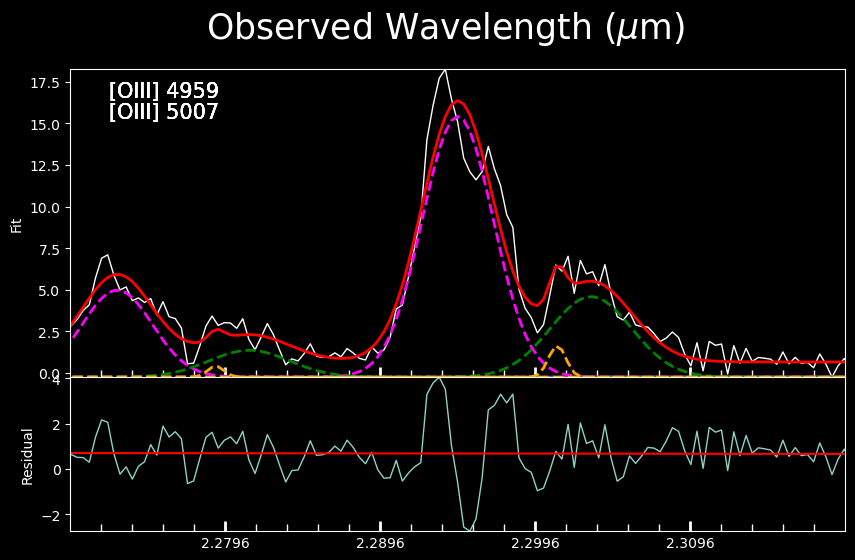

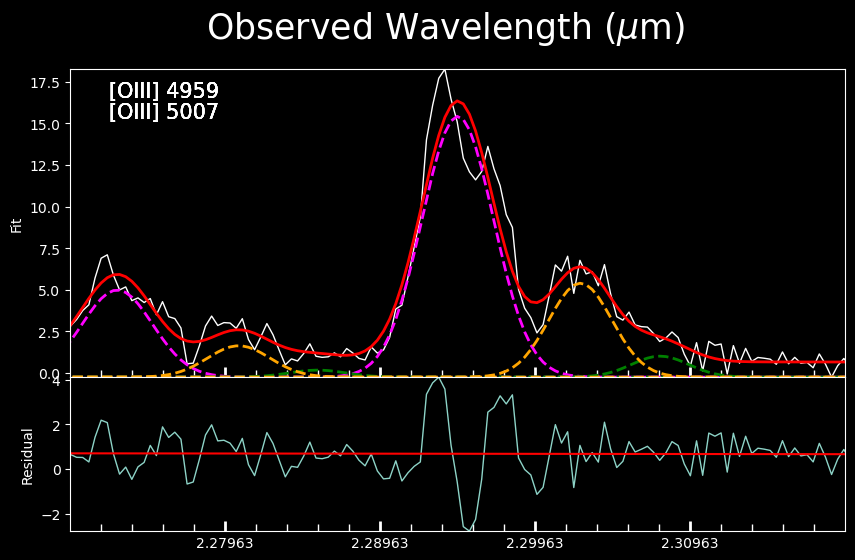

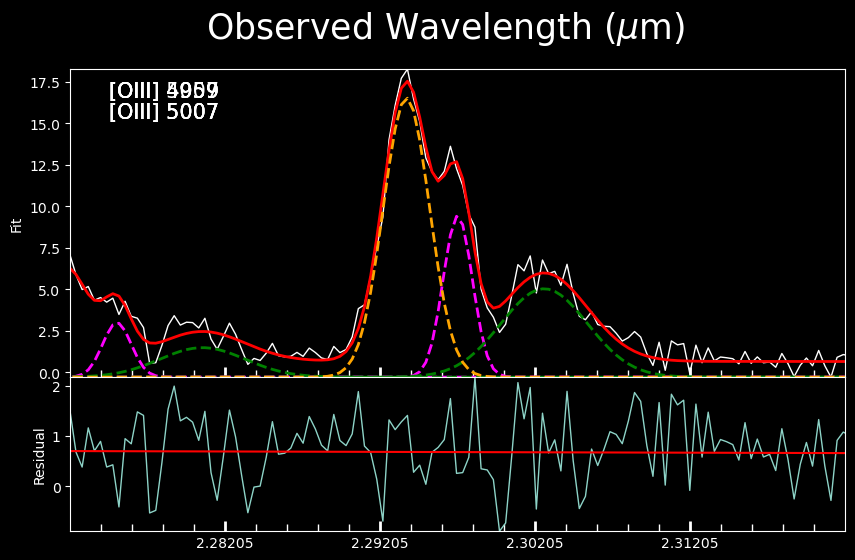

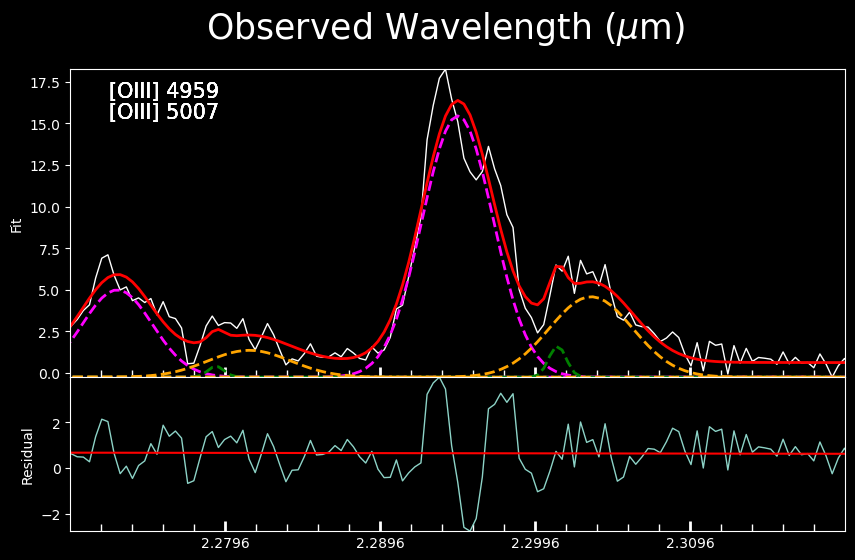

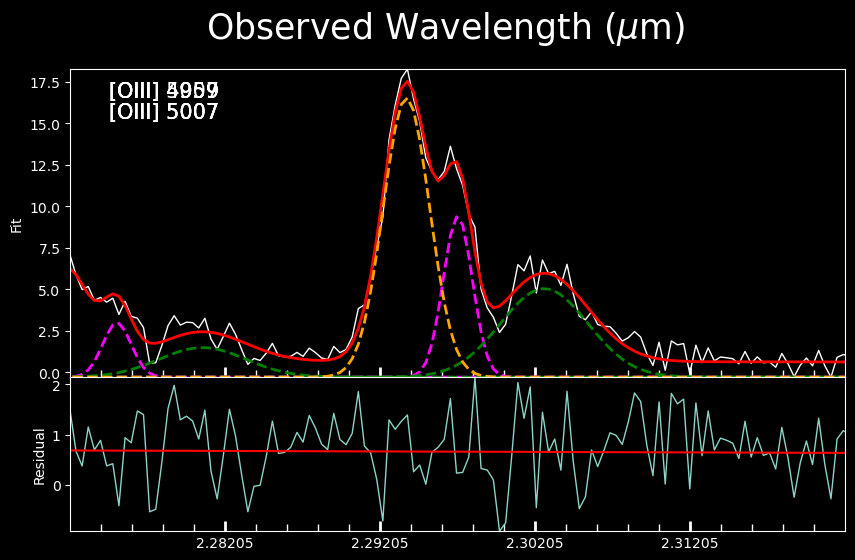

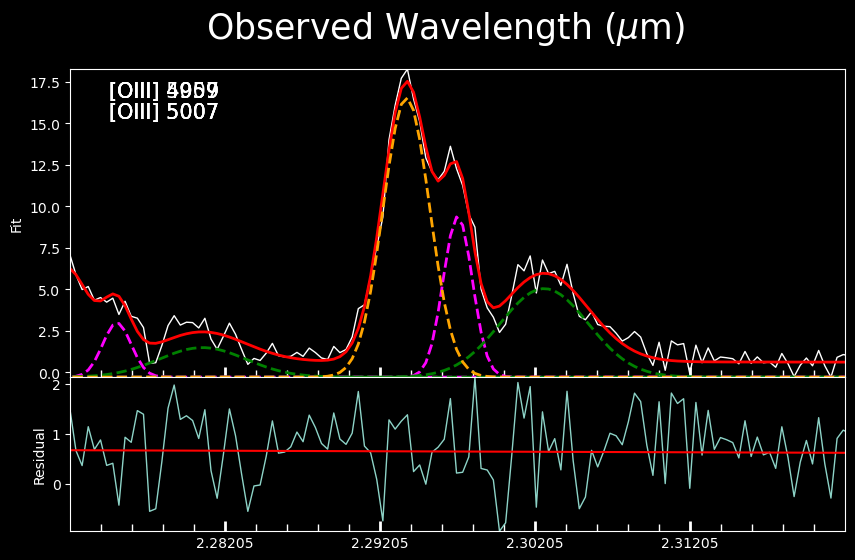

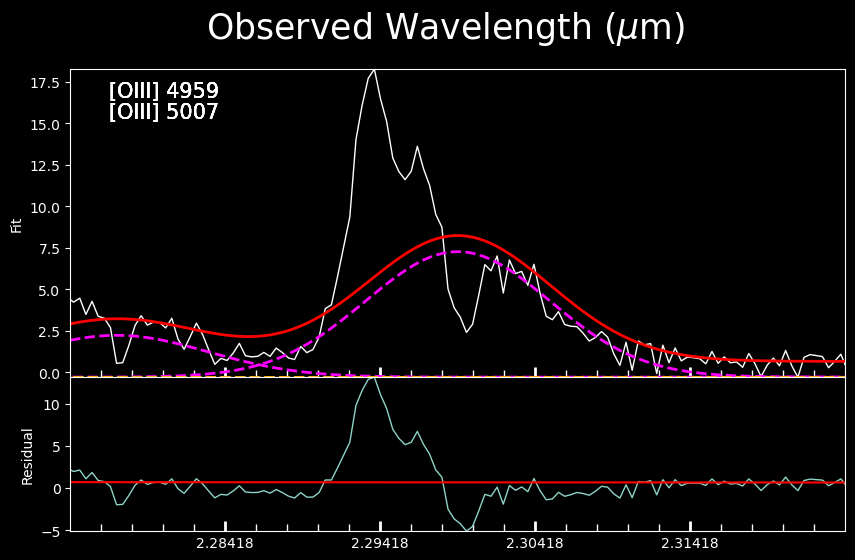

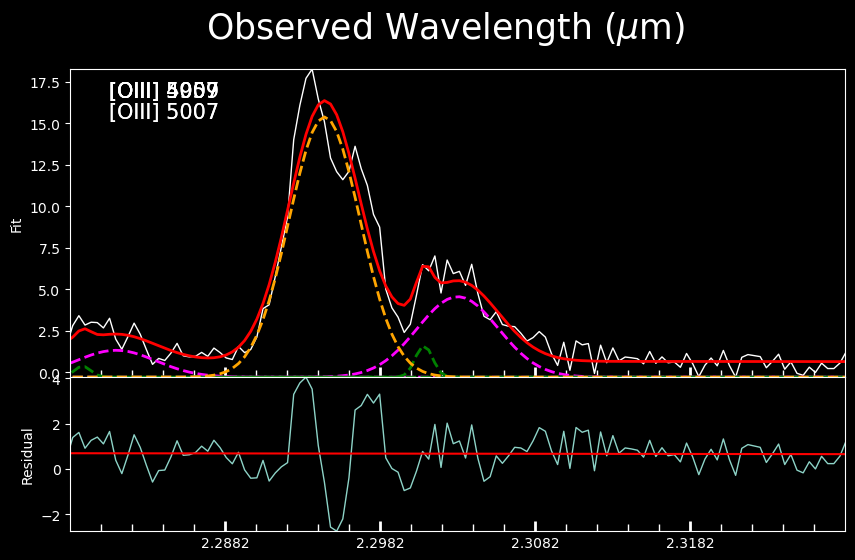

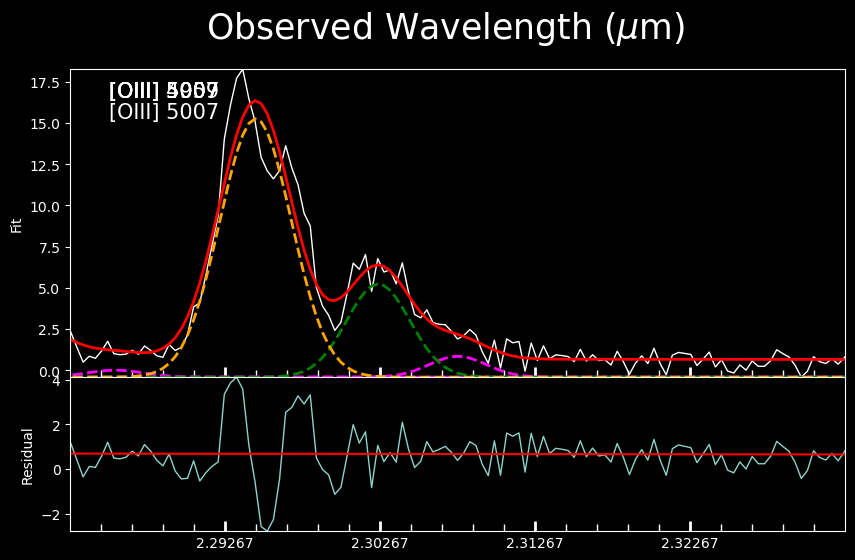

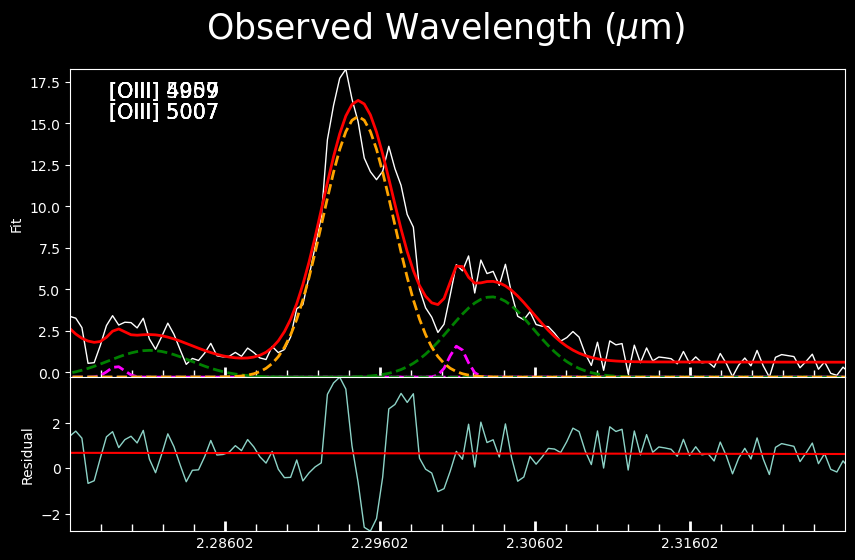

In [ ]:
col, row = 6-1, 25-1
ncomp_map = rmf_map
bic_values = []
component_combinations = list(itertools.combinations(range(5), 3))  # max of neighbours/all, this spaxel
for combination in component_combinations:
    for line, line_wavelength in zip(lines, line_wavelengths):
        # collect fit results from neighbouring spaxels
        collect_flux = []
        collect_wave = []
        collect_sig = []
        for c, r in zip(*get_already_fit_neighbours(col, row, final_map, ncomp_map)):
            collect_flux.append(q3do_array[c, r].line_fitpars["fluxpk"][line].take(combination).tolist())
            collect_wave.append(q3do_array[c, r].line_fitpars["wave"][line].take(combination).tolist())
            collect_sig.append(q3do_array[c, r].line_fitpars["sigma"][line].take(combination).tolist())
        # if step_number >= 12.:
        #     print(f"{step_number}: Flux {collect_flux}, Wave {collect_wave}, Sigma {collect_sig}")
        flux_init = np.nanmean(np.array(collect_flux), axis=0)
        wave_init = np.nanmean(np.array(collect_wave), axis=0)
        sig_init = np.nanmean(np.array(collect_sig), axis=0)
        # set inital values for new spaxel
        q3di.ncomp[line][col, row] = ncomp_map[col, row]
        for i, flx in enumerate(flux_init):
            q3di.fluxinit[line][col, row, i] = flx
        for i, wave in enumerate(wave_init):
            q3di.zinit_gas[line][col, row, i] = wave / line_wavelength - 1  # convert to redshift
        for i, sig in enumerate(sig_init):
            q3di.siginit_gas[line][col, row, i] = sig
    np.save(q3di.filename, q3di)
    q3dfit(q3di.filename, col+1, row+1, onefit=True, ncores=1, quiet=True, nocrash=True)
    q3do_new = load_q3dout(q3di, col+1, row+1)
    q3do_new.plot_line(q3di, plotargs={"line": ["[OIII]5007"], "nx": 1, "size": [0.05, 0.07], "figsize": (10,6)})
    bic_values.append(q3do_new.bic)
print(bic_values)
print(component_combinations[np.argmin(bic_values)])

In [16]:
cube, vormap = q3dutil.get_Cube(q3di)
cols = [1,2,3]
rows = [4,5,6]
nspax, colarr, rowarr = q3dutil.get_spaxels(cube, cols, rows)
print(nspax, colarr, rowarr)
cols = [1,2]
rows = [4,5]
nspax, colarr, rowarr = q3dutil.get_spaxels(cube, cols, rows)
print(nspax, colarr, rowarr)
cols = [1]
rows = [4]
nspax, colarr, rowarr = q3dutil.get_spaxels(cube, cols, rows)
print(nspax, colarr, rowarr)

3 [1, 2, 3] [4, 5, 6]
4 [0 0 1 1] [3 4 3 4]
1 [0] [3]


In [17]:
np.all(q3do_array[rmf_map == 5] != None)

np.True_

In [18]:
cols = [2, 6]
rows = [3, 7]
nspax, colarr, rowarr = q3dutil.get_spaxels(cube, cols, rows)
print(nspax, colarr, rowarr)

25 [1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5] [2 3 4 5 6 2 3 4 5 6 2 3 4 5 6 2 3 4 5 6 2 3 4 5 6]


In [19]:
test_list = [[1,2,3,4],[1,2,3,4],[1,2,3]]
np.array(test_list)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

In [ ]:
q3di_load: q3din = q3dutil.get_q3dio("input/q3di_4C1971_neighbour_method.npy")
q3di_load.fluxinit["[OIII]5007"][5,25,:]

array([12.41478939,  2.06494626, 11.22712291, 12.09774967, 15.27156254])

In [24]:
q3do_array[5,25].line_fitpars["fluxpk"][line]

12.428304138225572
2.087734382373715
11.260093769998518
12.004452008228393
15.28423108393127
